# The 24/7 Gap: Hourly Carbon Emissions of Data Centers in MISO
Python analysis of annual vs. hourly clean energy matching for a 100 MW data center, using EIA-930 hourly grid data (2025).

## 1. Load and clean EIA-930 data for MISO
Load 2025 hourly generation by fuel, filter to MISO, and calculate hourly grid carbon intensity (tCO2/MWh).


In [10]:
import pandas as pd

# 1. Load both halves of 2025 and stack them into one table
base = "https://www.eia.gov/electricity/gridmonitor/sixMonthFiles/"
files = ["EIA930_BALANCE_2025_Jan_Jun.csv", "EIA930_BALANCE_2025_Jul_Dec.csv"]
df = pd.concat([pd.read_csv(base + f, thousands=",", low_memory=False) for f in files],
               ignore_index=True)

# 2. Keep only MISO
miso = df[df["Balancing Authority"] == "MISO"].copy()

# 3. Group the EIA columns into simple fuel categories
p = "Net Generation (MW) from "
fuel_cols = {
    "coal":    [p + "Coal"],
    "gas":     [p + "Natural Gas"],
    "oil":     [p + "All Petroleum Products"],
    "nuclear": [p + "Nuclear"],
    "hydro":   [p + "Hydropower Excluding Pumped Storage"],
    "solar":   [p + "Solar without Integrated Battery Storage",
                p + "Solar with Integrated Battery Storage"],
    "wind":    [p + "Wind without Integrated Battery Storage",
                p + "Wind with Integrated Battery Storage"],
    "geothermal": [p + "Geothermal"],
    "other":   [p + "Other Fuel Sources", p + "Unknown Fuel Sources"],
}

# 4. Build a clean hourly table (MWh per hour, missing values = 0)
gen = pd.DataFrame()
gen["time"] = pd.to_datetime(miso["Local Time at End of Hour"], format="mixed")
for fuel, cols in fuel_cols.items():
    gen[fuel] = miso[cols].fillna(0).clip(lower=0).sum(axis=1)
gen = gen.sort_values("time").drop_duplicates("time").reset_index(drop=True)

# 5. Emission factors (tonnes CO2 per MWh) - approximate, cite EPA eGRID in memo
ef = {"coal": 1.0, "gas": 0.4, "oil": 0.8, "other": 0.5,
      "nuclear": 0, "hydro": 0, "solar": 0, "wind": 0, "geothermal": 0}

# 6. Hourly total generation, emissions, and carbon intensity
fuels = list(fuel_cols.keys())
gen["total_mwh"] = gen[fuels].sum(axis=1)
gen["co2_t"] = sum(gen[f] * ef[f] for f in fuels)
gen["carbon_intensity"] = gen["co2_t"] / gen["total_mwh"]   # tCO2 per MWh

# 7. Quick check
print("Hours of data:", len(gen))
print("Average carbon intensity (tCO2/MWh):", round(gen["carbon_intensity"].mean(), 3))
print(gen.head())

Hours of data: 8760
Average carbon intensity (tCO2/MWh): 0.432
                 time     coal      gas  oil  nuclear  hydro  solar     wind  \
0 2025-01-01 01:00:00  16829.0  16893.0  0.0  11136.0  928.0    1.0  19498.0   
1 2025-01-01 02:00:00  15606.0  15662.0  0.0  11135.0  888.0    1.0  19965.0   
2 2025-01-01 03:00:00  14800.0  15205.0  0.0  11138.0  860.0    1.0  20442.0   
3 2025-01-01 04:00:00  14500.0  14732.0  0.0  11138.0  860.0    1.0  20865.0   
4 2025-01-01 05:00:00  14932.0  15150.0  0.0  11139.0  859.0    1.0  20152.0   

   geothermal  other  total_mwh    co2_t  carbon_intensity  
0         0.0  295.0    65580.0  23733.7          0.361905  
1         0.0  272.0    63529.0  22006.8          0.346406  
2         0.0  270.0    62716.0  21017.0          0.335114  
3         0.0  271.0    62367.0  20528.3          0.329153  
4         0.0  272.0    62505.0  21128.0          0.338021  




 Data center emissions and grid carbon
 intensity by hour and month
Model a 100 MW data center running 24/7 and chart how grid carbon intensity varies by hour of day and by month.



Annual electricity use: 876,000 MWh
Annual CO2 emissions:   377,801 tonnes


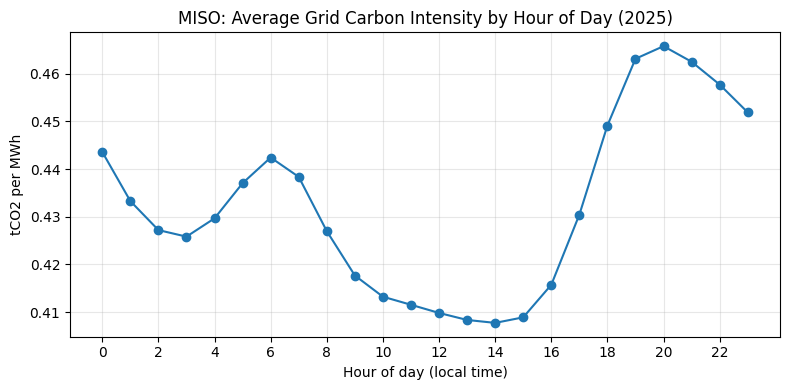

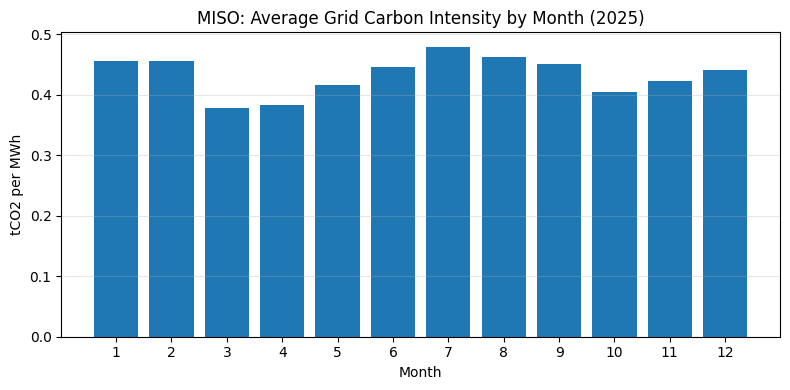

In [11]:
import matplotlib.pyplot as plt

# 1. A 100 MW data center running flat, 24/7 -> uses 100 MWh every hour
DC_MW = 100
gen["dc_co2_t"] = DC_MW * gen["carbon_intensity"]

annual_mwh = DC_MW * len(gen)
annual_co2 = gen["dc_co2_t"].sum()
print(f"Annual electricity use: {annual_mwh:,.0f} MWh")
print(f"Annual CO2 emissions:   {annual_co2:,.0f} tonnes")

# 2. Hour of day (EIA times are END of hour, so shift back 1 hour) and month
gen["hour"] = (gen["time"] - pd.Timedelta(hours=1)).dt.hour
gen["month"] = gen["time"].dt.month

# 3. Chart 1: average carbon intensity by hour of day
by_hour = gen.groupby("hour")["carbon_intensity"].mean()
plt.figure(figsize=(8, 4))
plt.plot(by_hour.index, by_hour.values, marker="o")
plt.title("MISO: Average Grid Carbon Intensity by Hour of Day (2025)")
plt.xlabel("Hour of day (local time)")
plt.ylabel("tCO2 per MWh")
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("miso_ci_by_hour.png", dpi=200)
plt.show()

# 4. Chart 2: average carbon intensity by month
by_month = gen.groupby("month")["carbon_intensity"].mean()
plt.figure(figsize=(8, 4))
plt.bar(by_month.index, by_month.values)
plt.title("MISO: Average Grid Carbon Intensity by Month (2025)")
plt.xlabel("Month")
plt.ylabel("tCO2 per MWh")
plt.xticks(range(1, 13))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("miso_ci_by_month.png", dpi=200)
plt.show()

## 3. Annual vs. hourly solar matching
Compare a solar contract sized to 100% of annual use with the share of hourly electricity it actually covers.


Annual matching claims:        100% clean
Hourly matching (real):        43% of electricity covered by solar
Hours fully covered by solar:  38% of the year
Emissions with no contract:    377,801 tCO2
Emissions still from grid:     219,704 tCO2 (58% of original)


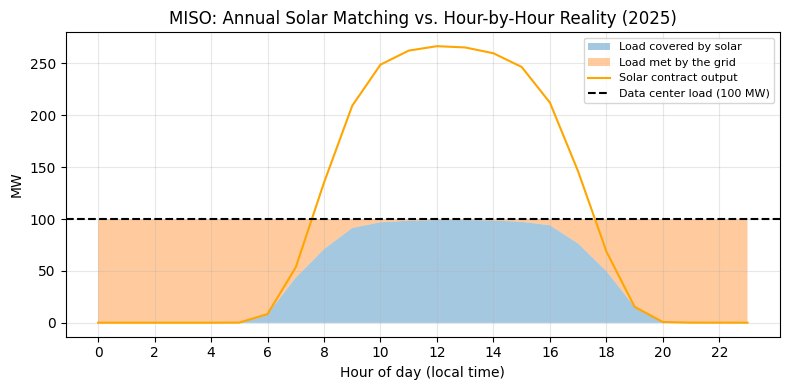

In [12]:
# 1. Build a solar contract sized to cover the data center's ANNUAL use,
#    using MISO's real hourly solar shape
gen["solar_contract"] = gen["solar"] * annual_mwh / gen["solar"].sum()

# 2. Each hour: how much of the 100 MW load does solar actually cover?
gen["covered"] = gen["solar_contract"].clip(upper=DC_MW)
gen["from_grid"] = DC_MW - gen["covered"]
gen["residual_co2"] = gen["from_grid"] * gen["carbon_intensity"]

# 3. Results
hourly_share = gen["covered"].sum() / annual_mwh
full_hours = (gen["solar_contract"] >= DC_MW).mean()
residual = gen["residual_co2"].sum()

print(f"Annual matching claims:        100% clean")
print(f"Hourly matching (real):        {hourly_share:.0%} of electricity covered by solar")
print(f"Hours fully covered by solar:  {full_hours:.0%} of the year")
print(f"Emissions with no contract:    {annual_co2:,.0f} tCO2")
print(f"Emissions still from grid:     {residual:,.0f} tCO2 "
      f"({residual/annual_co2:.0%} of original)")

# 4. Chart 3: an average day - data center load vs. solar supply
day = gen.groupby("hour")[["solar_contract", "covered"]].mean()
plt.figure(figsize=(8, 4))
plt.fill_between(day.index, day["covered"], alpha=0.4, label="Load covered by solar")
plt.fill_between(day.index, day["covered"], DC_MW, alpha=0.4, label="Load met by the grid")
plt.plot(day.index, day["solar_contract"], color="orange", label="Solar contract output")
plt.axhline(DC_MW, color="black", linestyle="--", label="Data center load (100 MW)")
plt.title("MISO: Annual Solar Matching vs. Hour-by-Hour Reality (2025)")
plt.xlabel("Hour of day (local time)")
plt.ylabel("MW")
plt.xticks(range(0, 24, 2))
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("miso_247_gap.png", dpi=200)
plt.show()

## 4. Clean energy portfolio comparison
Test hourly coverage and remaining emissions for solar, wind, a 50/50 mix, and an oversized 50/50 mix.

               Portfolio Hourly coverage Remaining tCO2 % of emissions left
              100% solar             43%        219,704                 58%
               100% wind             77%         96,078                 25%
      50/50 solar + wind             73%        110,190                 29%
50/50, oversized to 150%             85%         65,145                 17%


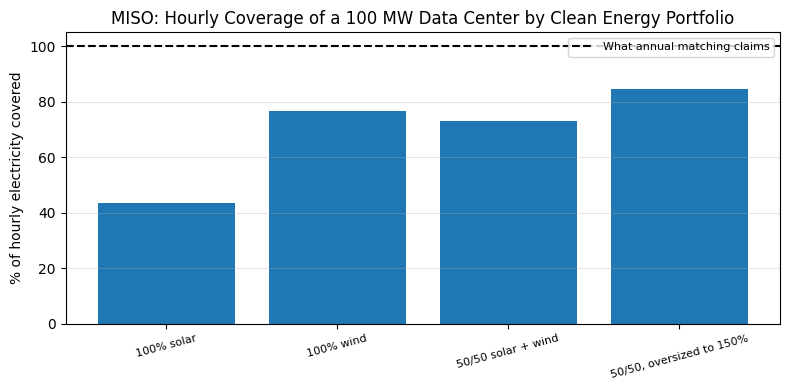

In [13]:
# Compare clean energy portfolios: how much hourly coverage does each achieve?
solar_shape = gen["solar"] / gen["solar"].sum()
wind_shape = gen["wind"] / gen["wind"].sum()

def test_portfolio(shape, size=1.0):
    contract = shape * annual_mwh * size          # size=1.0 means 100% of annual use
    covered = contract.clip(upper=DC_MW)
    coverage = covered.sum() / annual_mwh
    residual = ((DC_MW - covered) * gen["carbon_intensity"]).sum()
    return coverage, residual

portfolios = {
    "100% solar":              (solar_shape, 1.0),
    "100% wind":               (wind_shape, 1.0),
    "50/50 solar + wind":      (0.5 * solar_shape + 0.5 * wind_shape, 1.0),
    "50/50, oversized to 150%": (0.5 * solar_shape + 0.5 * wind_shape, 1.5),
}

rows = []
for name, (shape, size) in portfolios.items():
    cov, res = test_portfolio(shape, size)
    rows.append({"Portfolio": name, "Hourly coverage": cov,
                 "Remaining tCO2": res, "% of emissions left": res / annual_co2})
results = pd.DataFrame(rows)
print(results.to_string(index=False, formatters={
    "Hourly coverage": "{:.0%}".format,
    "Remaining tCO2": "{:,.0f}".format,
    "% of emissions left": "{:.0%}".format}))

# Chart 4: hourly coverage by portfolio
plt.figure(figsize=(8, 4))
plt.bar(results["Portfolio"], results["Hourly coverage"] * 100)
plt.axhline(100, color="black", linestyle="--", label="What annual matching claims")
plt.title("MISO: Hourly Coverage of a 100 MW Data Center by Clean Energy Portfolio")
plt.ylabel("% of hourly electricity covered")
plt.xticks(rotation=15, fontsize=8)
plt.legend(fontsize=8)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("miso_portfolios.png", dpi=200)
plt.show()